# Modeling (Jordan Blackman)

Using Nutrition Information to Classify Brand Tier (Premium Foods)

Mia Arnold - Jordan Blackman - Allen Ros

Shirley Marcos School of Engineering, University of San Diego

ADS-502 Applied Data Mining

# Goals

1. Data type transformation, remove features that would lead to overfitting, test train split, SMOTENC(nominal and continuous), Encoding, and Scaling.

2. Establish Baseline Model and evaluation metrics

3. Train initial models, tune hyperparameters (max leaf, minobservations, C for regularization), explore cost matrices, and explore bagging and boosting

4. Compare all models across multiple metrics beyond accuracy

Models to explore: Baseline (Majority Class), Naive Bayes, Decision Tree (CART, C5.0), kNN Classifier, Logistic Regression, SVC (Linear), SVC (RBF), SVC (Polynamial), SVC (Sigmoid), Random Forest Classifier (with bagging and boosting), XGBoost, Adaboost, and Neural Network.

# Data Type Transformation and Removing Overfitting Features

In [1]:
# import the necessary packages
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv("food_menu_nutrition_dataset.csv")

# log price, protein, and sugars to handle significant skew
df['log_price_usd_normalized'] = np.log1p(df['price_usd_normalized'])
df['log_protein_g'] = np.log1p(df['protein_g'])
df['log_sugars_g'] = np.log1p(df['sugars_g'])

# square root serving size, calories, fat, carbs, sodium to handle small skew
df['sqrt_serving_size_g'] = np.sqrt(df['serving_size_g'])
df['sqrt_calories'] = np.sqrt(df['calories'])
df['sqrt_total_fat_g'] = np.sqrt(df['total_fat_g'])
df['sqrt_total_carbs_g'] = np.sqrt(df['total_carbs_g'])
df['sqrt_sodium_mg'] = np.sqrt(df['sodium_mg'])

# flip average rating to handle left skew, units are flipped
reflect_constant = df['avg_rating'].max() + 1
df['trans_avg_rating'] = np.sqrt(reflect_constant - df['avg_rating'])

# is_bestseller is the only numerical variable left alone

# drop all original columns that were transformed
df = df.drop(columns=['price_usd_normalized', 'protein_g', 'sugars_g',
                      'serving_size_g', 'calories', 'total_fat_g',
                      'total_carbs_g', 'sodium_mg', 'avg_rating'])

# set up items that are nto being used for training models
items_to_drop = ['item_name', 'city', 'brand_name',
                 'brand_tier']

# get dependent and independent variables
tier_mapping = {'budget': 0, 'mid': 1, 'premium': 2}
Y = df['brand_tier'].map(tier_mapping)
X = df.drop(columns=items_to_drop)

# view the data
X.head().T

,0,1,2,3,4
item_category,Sandwich,Dessert,Salad,Dessert,Dessert
item_subcategory,Veg,Veg,Non-Veg,Veg,Veg
country,UK,USA,Canada,USA,USA
city_tier,metro,tier-2,metro,metro,metro
is_bestseller,0,0,0,0,0
log_price_usd_normalized,2.267994,1.329724,1.912501,2.248129,1.332366
log_protein_g,3.194583,0.832909,2.322388,1.84055,0.0
log_sugars_g,2.572612,3.288402,1.88707,4.084294,3.895894
sqrt_serving_size_g,14.996666,12.316655,17.149344,9.364828,11.198214
sqrt_calories,20.935616,18.398369,10.26645,20.107213,19.118054


# Test Train Split

In [2]:
# test train split with random state and stratification
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

# SMOTE

In [3]:
# Oversample the minority class (Premium)
from imblearn.over_sampling import SMOTENC

cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.drop(
    items_to_drop, errors='ignore').tolist()

cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

print("Before SMOTE")
print(Y_train.value_counts())

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train, Y_train = smote_nc.fit_resample(X_train, Y_train)

print("After SMOTE:")
print(Y_train.value_counts())

Before SMOTE
brand_tier
0    3532
1    1872
2     596
Name: count, dtype: int64
After SMOTE:
brand_tier
0    3532
1    3532
2    3532
Name: count, dtype: int64


# Encoding

In [4]:
# encode variables
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# align encoded variables
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns, fill_value=0)

# Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

# scale variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Establish Evaluation Function

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# define a reusable function to calculate evaluation metrics for all models


def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model", verbose=True):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    roc_auc = None
    if y_prob is not None:
        try:
            roc_auc = roc_auc_score(
                y_true, y_prob, multi_class='ovr', average='macro')
        except ValueError:
            roc_auc = None

    if verbose:
        print(f"--- {model_name} Evaluation ---")
        print(f"Accuracy:     {acc:.4f}")
        print(f"Precision:    {prec:.4f} (Macro)")
        print(f"Recall:       {rec:.4f} (Macro)")
        print(f"F1-Score:     {f1:.4f} (Macro)")
        if roc_auc is not None:
            print(f"ROC AUC:      {roc_auc:.4f}")
        print("-" * 30 + "\n")

        fig, ax = plt.subplots(figsize=(5, 5))
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, ax=ax, cmap='Blues', colorbar=False
        )
        ax.set_title(f"Confusion Matrix: {model_name}")
        plt.tight_layout()
        plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc
    }

# Establish Reusable Modeling Function

In [7]:
# establish a function trains and evaluates all models
def train_and_evaluate(model, x_train, y_train, x_test, y_test, model_name, verbose=True):

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    y_prob = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)

    metrics = evaluate_model(y_test, y_pred, y_prob, model_name, verbose)

    return metrics

# Establish Baseline Model

--- Baseline (Majority Class) Evaluation ---
Accuracy:     0.5887
Precision:    0.1962 (Macro)
Recall:       0.3333 (Macro)
F1-Score:     0.2470 (Macro)
ROC AUC:      0.5000
------------------------------



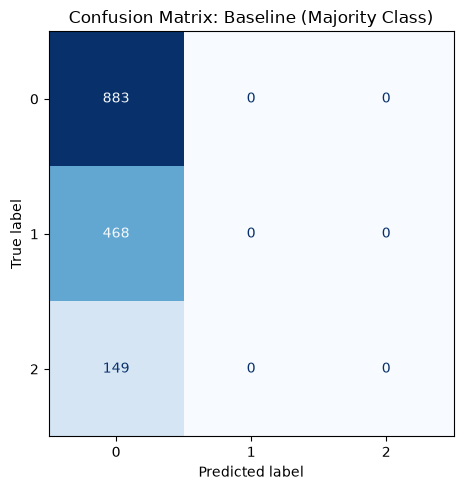

In [8]:
# dummy model always predicts the majority class
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="constant", constant=0)

baseline_metrics = train_and_evaluate(
    baseline,
    X_train,
    Y_train,
    X_test,
    Y_test,
    model_name="Baseline (Majority Class)"
)

# Train Initial Models

--- Naive Bayes 1 Evaluation ---
Accuracy:     0.6573
Precision:    0.5785 (Macro)
Recall:       0.6223 (Macro)
F1-Score:     0.5937 (Macro)
ROC AUC:      0.8222
------------------------------



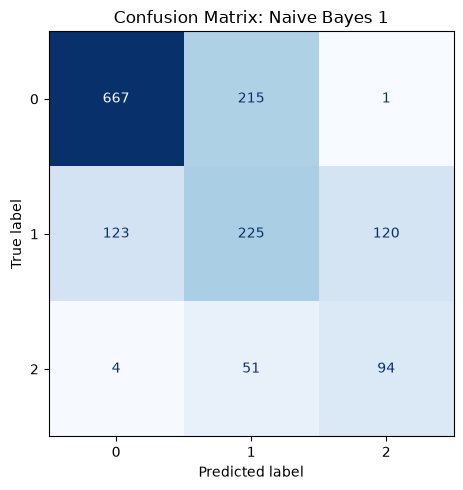

In [9]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_1 = GaussianNB()

nb_1_metrics = train_and_evaluate(
    nb_1,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Naive Bayes 1"
)

--- Cart 1 Evaluation ---
Accuracy:     0.8627
Precision:    0.8020 (Macro)
Recall:       0.8515 (Macro)
F1-Score:     0.8227 (Macro)
ROC AUC:      0.8916
------------------------------



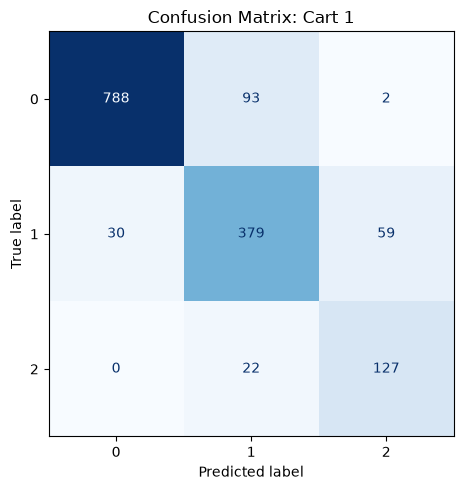

In [10]:
# Decision Tree (CART)

from sklearn.tree import DecisionTreeClassifier

cart_1 = DecisionTreeClassifier(random_state=42, class_weight=None)

cart_1_metrics = train_and_evaluate(
    cart_1,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Cart 1"
)

--- C5.0 1 Evaluation ---
Accuracy:     0.8513
Precision:    0.7845 (Macro)
Recall:       0.8301 (Macro)
F1-Score:     0.8035 (Macro)
ROC AUC:      0.8772
------------------------------



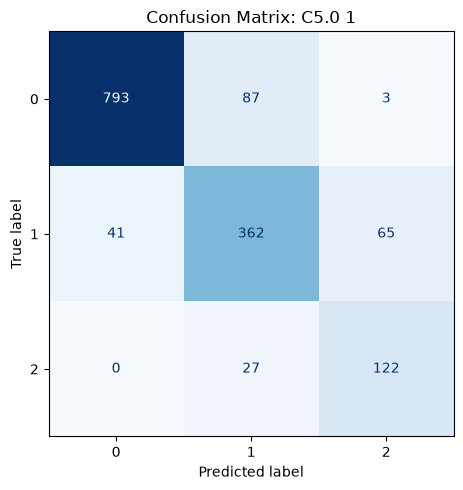

In [11]:
# Decision Tree (C5.0)

cart_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

c5_metrics = train_and_evaluate(
    cart_entropy,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="C5.0 1"
)

--- KNN (n=4) Evaluation ---
Accuracy:     0.6587
Precision:    0.5689 (Macro)
Recall:       0.5746 (Macro)
F1-Score:     0.5716 (Macro)
ROC AUC:      0.7526
------------------------------



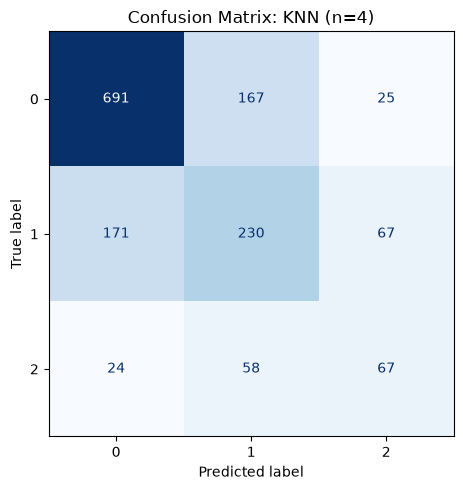

In [12]:
# kNN Classifier (selected)
from sklearn.neighbors import KNeighborsClassifier

knn_1 = KNeighborsClassifier(n_neighbors=4)

knn_metrics = train_and_evaluate(
    knn_1,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="KNN (n=4)"
)

--- Logistic Regression Evaluation ---
Accuracy:     0.8967
Precision:    0.8448 (Macro)
Recall:       0.8684 (Macro)
F1-Score:     0.8557 (Macro)
ROC AUC:      0.9801
------------------------------



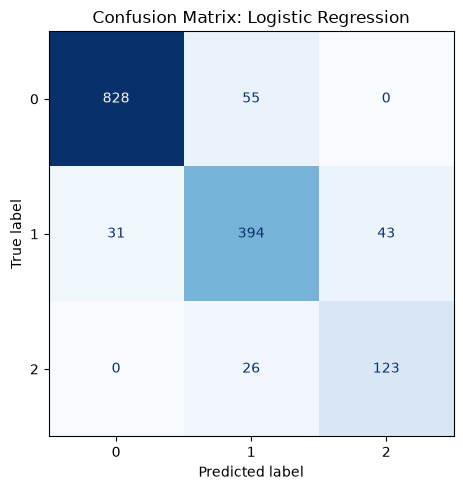

In [13]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

log_reg_1 = LogisticRegression(random_state=42, max_iter=1000)

log_reg_1_metrics = train_and_evaluate(
    log_reg_1,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Logistic Regression"

)

--- SVC Linear Evaluation ---
Accuracy:     0.9093
Precision:    0.8676 (Macro)
Recall:       0.8779 (Macro)
F1-Score:     0.8726 (Macro)
ROC AUC:      0.9693
------------------------------



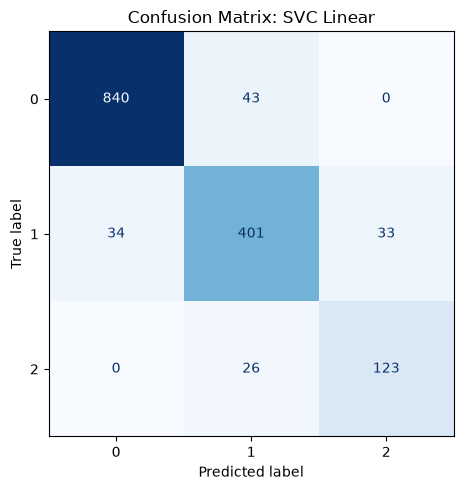

In [14]:
# SVC (Linear)

from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

base_svc_linear = SVC(kernel='linear', random_state=42)
svc_linear = CalibratedClassifierCV(base_svc_linear, ensemble=False)

svc_linear_metrics = train_and_evaluate(
    svc_linear,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="SVC Linear"
)

--- SVC RBF Evaluation ---
Accuracy:     0.8873
Precision:    0.8558 (Macro)
Recall:       0.8489 (Macro)
F1-Score:     0.8523 (Macro)
ROC AUC:      0.9491
------------------------------



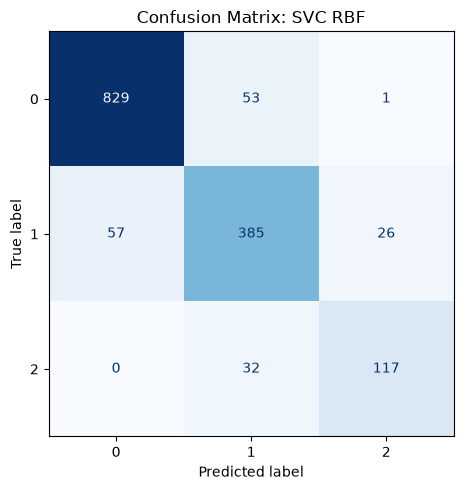

In [15]:
# SVC (RBF)
base_svc_rbf = SVC(kernel='rbf', random_state=42)
svc_rbf = CalibratedClassifierCV(base_svc_rbf, ensemble=False)

svc_rbf_metrics = train_and_evaluate(
    svc_rbf,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="SVC RBF"
)

--- SVC Polynomial Evaluation ---
Accuracy:     0.8593
Precision:    0.8133 (Macro)
Recall:       0.8282 (Macro)
F1-Score:     0.8204 (Macro)
ROC AUC:      0.9316
------------------------------



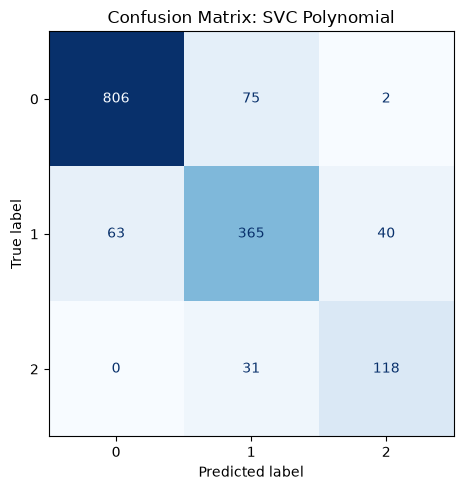

In [16]:
# SVC (Polynomial)
base_svc_poly = SVC(kernel='poly', random_state=42)
svc_poly = CalibratedClassifierCV(base_svc_poly, ensemble=False)

svc_poly_metrics = train_and_evaluate(
    svc_poly,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="SVC Polynomial"
)

--- SVC Sigmoid Evaluation ---
Accuracy:     0.7367
Precision:    0.6633 (Macro)
Recall:       0.7248 (Macro)
F1-Score:     0.6842 (Macro)
ROC AUC:      0.8781
------------------------------



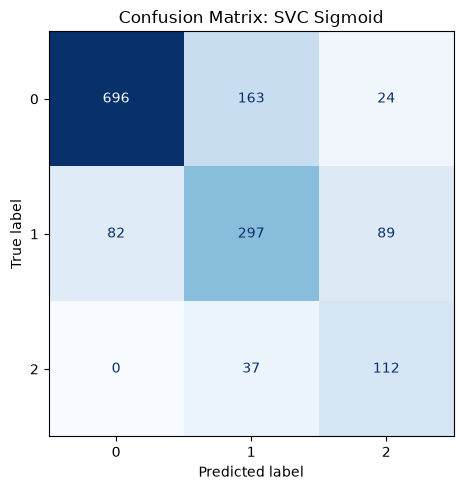

In [17]:
# SVC (Sigmoid)
base_svc_sigmoid = SVC(kernel='sigmoid', random_state=42)
svc_sigmoid = CalibratedClassifierCV(base_svc_sigmoid, ensemble=False)

svc_sigmoid_metrics = train_and_evaluate(
    svc_sigmoid,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="SVC Sigmoid"
)

--- Random Forest Evaluation ---
Accuracy:     0.9067
Precision:    0.8825 (Macro)
Recall:       0.8619 (Macro)
F1-Score:     0.8716 (Macro)
ROC AUC:      0.9737
------------------------------



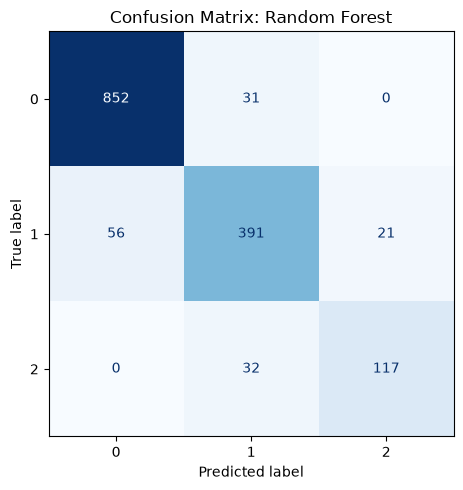

In [18]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_metrics = train_and_evaluate(
    rf_model,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Random Forest"
)

--- Balanced Random Forest Evaluation ---
Accuracy:     0.9067
Precision:    0.8772 (Macro)
Recall:       0.8671 (Macro)
F1-Score:     0.8720 (Macro)
ROC AUC:      0.9738
------------------------------



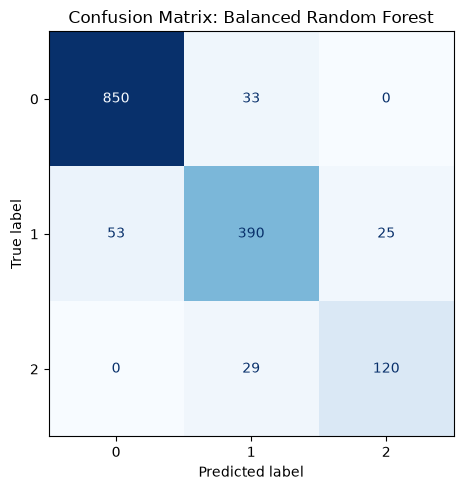

In [19]:
# Balanced Random Forest Classifier
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(n_estimators=100, random_state=42)

brf_metrics = train_and_evaluate(
    brf,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Balanced Random Forest"
)

/opt/anaconda3/envs/ads502/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:48:02] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1780806848081/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Evaluation ---
Accuracy:     0.9147
Precision:    0.8845 (Macro)
Recall:       0.8850 (Macro)
F1-Score:     0.8847 (Macro)
ROC AUC:      0.9776
------------------------------



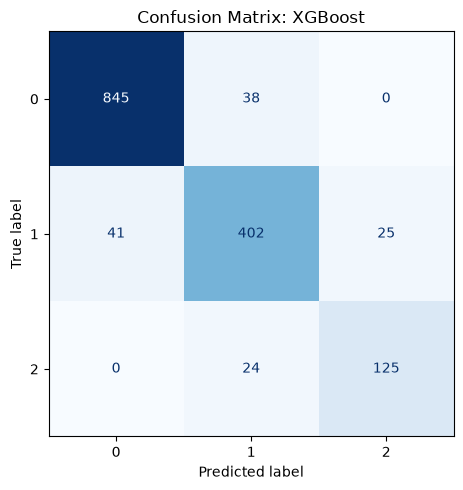

In [29]:
# XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_metrics = train_and_evaluate(
    xgb_model,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="XGBoost"
)

--- AdaBoost Evaluation ---
Accuracy:     0.6913
Precision:    0.5920 (Macro)
Recall:       0.6933 (Macro)
F1-Score:     0.6010 (Macro)
ROC AUC:      0.8826
------------------------------



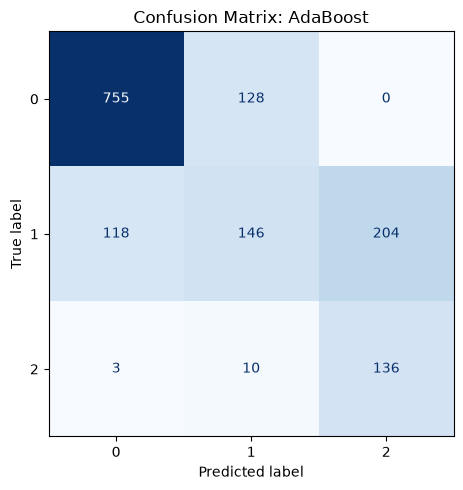

In [21]:
# AdaBoost with Random Forest Base

from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada_metrics = train_and_evaluate(
    ada_model,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="AdaBoost"
)

--- Neural Network (Regularized) Evaluation ---
Accuracy:     0.8773
Precision:    0.8309 (Macro)
Recall:       0.8550 (Macro)
F1-Score:     0.8417 (Macro)
ROC AUC:      0.9731
------------------------------



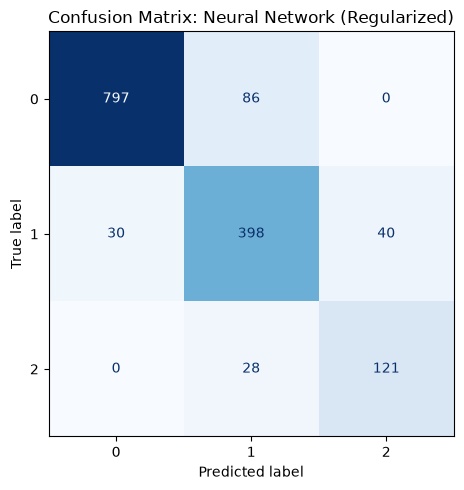

In [22]:
# Neural Network

from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.05,
    max_iter=1000,
    learning_rate_init=0.001,
    early_stopping=True,
    random_state=42
)

mlp_metrics = train_and_evaluate(
    mlp_model,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Neural Network (Regularized)"
)

# Compare Initial Models

In [33]:
# Compare all model results
model_results = [val for name, val in globals().items(
) if 'metrics' in name and isinstance(val, dict)]

# 2. Convert to DataFrame
results_df = pd.DataFrame(model_results)

# 3. Set the 'model' column as the index for better readability
results_df.set_index('model', inplace=True)

# 4. Display the table
results_df.sort_values(by='roc_auc', ascending=False). round(2)

,accuracy,precision,recall,f1_score,roc_auc
model,,,,,
Logistic Regression,0.90,0.84,0.87,0.86,0.98
XGBoost,0.91,0.88,0.88,0.88,0.98
Tuned XGBoost,0.91,0.87,0.86,0.86,0.98
Balanced Random Forest,0.91,0.88,0.87,0.87,0.97
Random Forest,0.91,0.88,0.86,0.87,0.97
Neural Network (Regularized),0.88,0.83,0.86,0.84,0.97
SVC Linear,0.91,0.87,0.88,0.87,0.97
SVC RBF,0.89,0.86,0.85,0.85,0.95
SVC Polynomial,0.86,0.81,0.83,0.82,0.93


# Explore Hyperparameters and Cost Matrices

In [24]:
# kNN Classifier tuning k

all_results = []

for k in range(1, 101):
    knn = KNeighborsClassifier(n_neighbors=k)

    metrics = train_and_evaluate(
        knn, X_train_scaled, Y_train, X_test_scaled, Y_test,
        model_name=f"k={k}", verbose=False
    )
    all_results.append(metrics)

df = pd.DataFrame(all_results)

df['k'] = df['model'].str.extract('(\d+)').astype(int)

metrics_to_check = ['accuracy', 'precision',
                    'recall',
                    'f1_score', 'roc_auc']

for metric in metrics_to_check:
    print(f"--- Top 2 k-values for {metric.upper()} ---")

    top_2 = df.nlargest(2, metric)

    for i, row in top_2.iterrows():
        print(f"Rank {i+1}: k = {row['k']} | Score = {row[metric]:.4f}")
    print("\n")

--- Top 2 k-values for ACCURACY ---
Rank 2: k = 2 | Score = 0.6767
Rank 4: k = 4 | Score = 0.6587


--- Top 2 k-values for PRECISION ---
Rank 2: k = 2 | Score = 0.6073
Rank 6: k = 6 | Score = 0.5715


--- Top 2 k-values for RECALL ---
Rank 94: k = 94 | Score = 0.6021
Rank 92: k = 92 | Score = 0.6008


--- Top 2 k-values for F1_SCORE ---
Rank 8: k = 8 | Score = 0.5782
Rank 6: k = 6 | Score = 0.5779


--- Top 2 k-values for ROC_AUC ---
Rank 9: k = 9 | Score = 0.7707
Rank 8: k = 8 | Score = 0.7704




Fitting 3 folds for each of 20 candidates, totalling 60 fits


/opt/anaconda3/envs/ads502/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/envs/ads502/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/ads502/lib/python3.11/site-packages/sklearn/utils/validation.py", line 80, in inner_f
    return f(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/ads502/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/ads502/l

Best Parameters: {'colsample_bytree': np.float64(0.749816047538945), 'learning_rate': np.float64(0.2952142919229748), 'max_depth': 5, 'n_estimators': 121, 'subsample': np.float64(0.8394633936788146)}
--- Tuned XGBoost Evaluation ---
Accuracy:     0.9087
Precision:    0.8681 (Macro)
Recall:       0.8588 (Macro)
F1-Score:     0.8633 (Macro)
ROC AUC:      0.9752
------------------------------



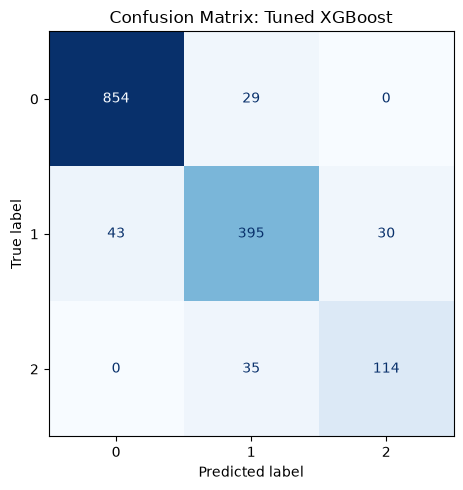

In [30]:
# XGBoost with tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

tuned_xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

param_dist = {
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'n_estimators': randint(50, 300),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

random_search = RandomizedSearchCV(
    estimator=tuned_xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_scaled, Y_train)

print(f"Best Parameters: {random_search.best_params_}")

best_xgb = random_search.best_estimator_
tuned_xgb_metrics = train_and_evaluate(
    best_xgb,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Tuned XGBoost"
)

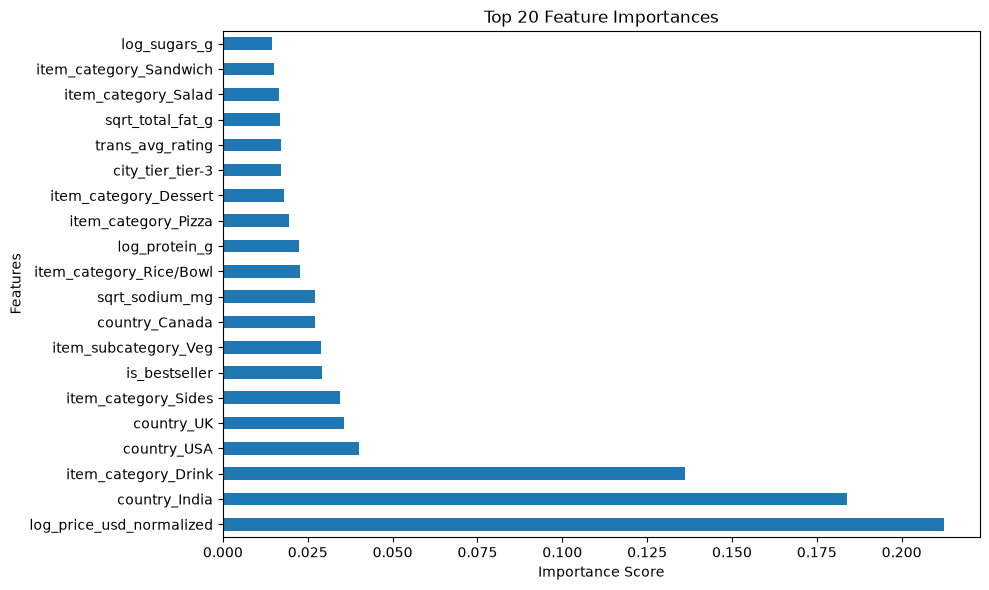

In [31]:
# Get feature importances
importances = best_xgb.feature_importances_

feature_names = X_train_encoded.columns

feat_imp = pd.Series(
    importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(20).plot(kind='barh', title="Top 20 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

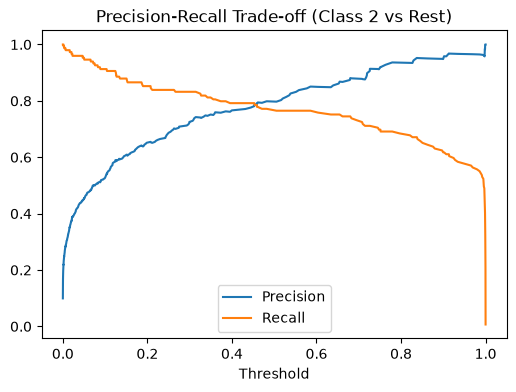

In [32]:
from sklearn.metrics import precision_recall_curve

target_class_idx = 2

y_true_binary = (Y_test == target_class_idx).astype(int)

y_probs_class = best_xgb.predict_proba(X_test_scaled)[:, target_class_idx]

precision, recall, thresholds = precision_recall_curve(
    y_true_binary, y_probs_class)

plt.figure(figsize=(6, 4))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.title(f"Precision-Recall Trade-off (Class {target_class_idx} vs Rest)")
plt.show()

# Compare all models